<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/DS/Titanic_Hypothesis_Testing_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing Tutorial Using the Titanic Dataset

This tutorial demonstrates the complete **6-step hypothesis testing process** using the Titanic dataset available in Seaborn.

```python
import seaborn as sns
titanic = sns.load_dataset("titanic")
```


In [5]:
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Task 1 – Independent Samples T-Test

## Business Question
**Do male and female passengers have different average ages?**

### Step 1 – Define the Hypotheses
- **H₀:** The average age of male passengers equals the average age of female passengers.
- **H₁:** The average ages are different.

### Step 2 – Choose the Significance Level
Use **α = 0.05**.

### Step 3 – Collect and Analyze the Data
Variables:
- sex (Categorical)
- age (Numerical)

Calculate the average age for each group.

### Step 4 – Calculate the Test Statistic
Use an **Independent Samples T-test** because:
- two independent groups
- one numerical variable

### Step 5 – Make the Decision
If **p < 0.05**, reject H₀.

### Step 6 – Interpret the Results
Explain whether passenger sex is associated with different average ages.


sex
female    27.915709
male      30.726645
Name: age, dtype: float64
T statistic: 2.5258975171938896
P-value: 0.011814913211889735
T=2.5259, p=0.0118
Decision: Reject H0
Conclusion: Male and female passengers have significantly different average ages.


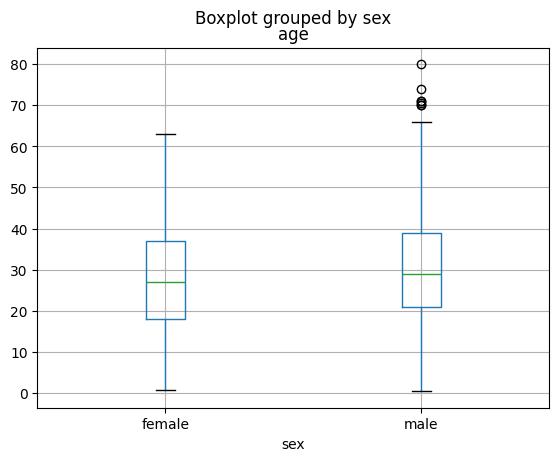

In [13]:
df=titanic[['sex','age']].dropna()

male=df[df.sex=='male']['age']
female=df[df.sex=='female']['age']

print(df.groupby('sex')['age'].mean())

t,p=stats.ttest_ind(male,female,equal_var=False)
print("T statistic:",t)
print("P-value:",p)
print(f"T={t:.4f}, p={p:.4f}")
if p<0.05:
    print("Decision: Reject H0")
    print("Conclusion: Male and female passengers have significantly different average ages.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: No significant difference in average ages.")
df.boxplot(column='age',by='sex')
plt.show()

# Task 2 – One-Way ANOVA

## Business Question
**Does passenger class affect the average fare paid?**

### Step 1
- **H₀:** Average fare is equal across all passenger classes.
- **H₁:** At least one class has a different average fare.

### Step 2
Use **α = 0.05**.

### Step 3
Variables:
- class (Categorical)
- fare (Numerical)

Calculate average fare for each class.

### Step 4
Use **One-Way ANOVA** because there are more than two independent groups.

### Step 5
Reject H₀ if **p < 0.05**.

### Step 6
Explain whether passenger class influences ticket price.


/tmp/ipykernel_1106/1473441826.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['fare'].mean())
/tmp/ipykernel_1106/1473441826.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups=[g['fare'].values for _,g in df.groupby('class')]


class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64
F statistic: 242.34415651744814
P-value: 1.0313763209141171e-84
F=242.3442, p=0.0000
Decision: Reject H0
Conclusion: Passenger class significantly affects fare.


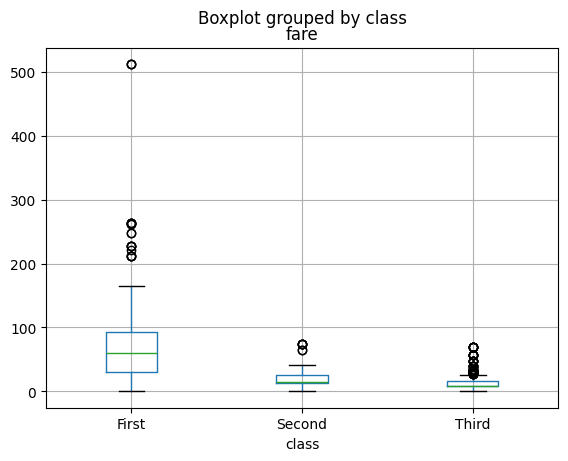

In [14]:
df=titanic[['class','fare']].dropna()

print(df.groupby('class')['fare'].mean())

groups=[g['fare'].values for _,g in df.groupby('class')]

F,p=stats.f_oneway(*groups)

print("F statistic:",F)
print("P-value:",p)
print(f"F={F:.4f}, p={p:.4f}")
if p<0.05:
    print("Decision: Reject H0")
    print("Conclusion: Passenger class significantly affects fare.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: No significant difference in fares.")
df.boxplot(column='fare',by='class')
plt.show()

# Task 3 – Chi-Square Test of Independence

## Business Question
**Is survival independent of passenger sex?**

### Step 1
- **H₀:** Survival and sex are independent.
- **H₁:** Survival and sex are associated.

### Step 2
Use **α = 0.05**.

### Step 3
Variables:
- survived (Categorical)
- sex (Categorical)

Create a contingency table.

### Step 4
Use a **Chi-Square Test of Independence** because both variables are categorical.

### Step 5
Reject H₀ if **p < 0.05**.

### Step 6
Explain whether survival depended on passenger sex.


### What is "Degrees of Freedom" in Chi-Square?

In a Chi-square test, **degrees of freedom (dof)** represent the number of independent pieces of information used to calculate the test statistic. More simply, it's the number of values in the final calculation of a statistic that are free to vary.

For a Chi-square test of independence with a contingency table (like the one we'll create for `sex` and `survived`), the degrees of freedom are calculated as:

**(Number of Rows - 1) * (Number of Columns - 1)**

For example, if your contingency table has 2 rows and 2 columns, the degrees of freedom would be (2 - 1) * (2 - 1) = 1 * 1 = 1.

The degrees of freedom are essential because they determine the shape of the Chi-square distribution, which in turn is used to find the p-value for your observed test statistic. This p-value helps us decide whether to reject the null hypothesis.

In [15]:
table=pd.crosstab(titanic['sex'],titanic['survived'])
print(table)

chi2,p,dof,expected=stats.chi2_contingency(table)

print("Chi-square:",chi2)
print("Degrees of Freedom:",dof)
print("P-value:",p)

print("\nExpected Frequencies")
print(pd.DataFrame(expected,index=table.index,columns=table.columns))

print(f"Chi2={chi2:.4f}, p={p:.4f}")
if p<0.05:
    print("Decision: Reject H0")
    print("Conclusion: Survival is associated with passenger sex.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: Survival is independent of passenger sex.")

survived    0    1
sex               
female     81  233
male      468  109
Chi-square: 260.71702016732104
Degrees of Freedom: 1
P-value: 1.1973570627755645e-58

Expected Frequencies
survived           0           1
sex                             
female    193.474747  120.525253
male      355.525253  221.474747
Chi2=260.7170, p=0.0000
Decision: Reject H0
Conclusion: Survival is associated with passenger sex.


# Final Summary

| Test | Variables | Purpose |
|------|-----------|---------|
| T-test | Sex vs Age | Compare two group means |
| ANOVA | Class vs Fare | Compare three group means |
| Chi-Square | Sex vs Survival | Test relationship between two categorical variables |

For every hypothesis test:
1. Define hypotheses
2. Choose α = 0.05
3. Analyze the data
4. Calculate the test statistic
5. Compare the p-value with α
6. Draw a practical conclusion
